# Deck Census, Similarity, and Isolation Exploration

## Goal

Build a reproducible census of exact 60-card decks, compare their similarity, and identify robust Deck-Isolation and Archetype-Isolation candidates. This notebook only recommends candidates; it does not create a training/validation split.

## Setup

The only paths to adjust are visible below. Exact deck IDs and archetypes are computed by reusable functions in `deck.analysis`.

In [1]:
import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd() / 'imitation_learning', Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'deck' / 'analysis.py').is_file():
            return candidate.resolve()
    raise FileNotFoundError('Could not locate the imitation_learning project root')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import deck.analysis as deck_analysis
importlib.reload(deck_analysis)

from deck.analysis import (
    CardCatalog,
    IsolationSamplingError,
    annotate_deck_facts,
    audit_deck_archetype_selection,
    build_archetype_isolation_candidates,
    build_archetype_selection_details,
    build_deck_census,
    build_deck_isolation_candidates,
    build_top_deck_archetype_candidates,
    build_similarity_pairs,
    load_deck_rows,
    roll_archetype_isolation_selection,
    roll_deck_isolation_selection,
    roll_top_deck_archetype_selection,
)

DECK_DATA_DIR = PROJECT_ROOT / 'data' / 'deck'
CARD_TABLE_PATH = PROJECT_ROOT.parent / 'pokemon_tcg_ai_battle' / 'EN_Card_Data.csv'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'deck_analysis'

print('Deck data:', DECK_DATA_DIR)
print('Card table:', CARD_TABLE_PATH)
print('Output:', OUTPUT_DIR)

Deck data: D:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck
Card table: D:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\pokemon_tcg_ai_battle\EN_Card_Data.csv
Output: D:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_analysis


## Load & Validate

Every successfully extracted episode must have exactly two rows, players 0 and 1, and each row must contain a valid 60-card list.

In [2]:
deck_paths = sorted(DECK_DATA_DIR.glob('*.decks.csv'))
if not deck_paths:
    raise FileNotFoundError(f'No .decks.csv files found under {DECK_DATA_DIR}')

deck_facts = load_deck_rows(deck_paths)
catalog = CardCatalog.from_csv(CARD_TABLE_PATH)

print('Files:', len(deck_paths))
print('Deck rows:', len(deck_facts))
print('Episodes:', deck_facts[['date', 'episode_id']].drop_duplicates().shape[0])
print('Dates:', ', '.join(sorted(deck_facts['date'].unique())))

fact_preview = deck_facts.drop(columns=['deck']).head(10)
display(fact_preview)

Files: 43
Deck rows: 421334
Episodes: 210667
Dates: 6.26, 6.27, 6.28, 6.29, 6.30, 7.1, 7.10, 7.11, 7.12, 7.13, 7.14, 7.15, 7.16, 7.17, 7.18, 7.19, 7.2, 7.20, 7.21, 7.22, 7.23, 7.24, 7.25, 7.26, 7.27, 7.28, 7.29, 7.3, 7.30, 7.31, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7


,date,episode_id,player,reward,result,source_file
0,6.26,81919329,0,-1.0,loss,6.26.decks.csv
1,6.26,81919329,1,1.0,win,6.26.decks.csv
2,6.26,81919334,0,-1.0,loss,6.26.decks.csv
3,6.26,81919334,1,1.0,win,6.26.decks.csv
4,6.26,81919351,0,-1.0,loss,6.26.decks.csv
5,6.26,81919351,1,1.0,win,6.26.decks.csv
6,6.26,81919355,0,1.0,win,6.26.decks.csv
7,6.26,81919355,1,-1.0,loss,6.26.decks.csv
8,6.26,81919359,0,1.0,win,6.26.decks.csv
9,6.26,81919359,1,-1.0,loss,6.26.decks.csv


## Deck Census

A row represents one exact sorted 60-card multiset. Rank follows usage, while `deck_id` remains stable across reruns.

In [5]:
deck_summary = build_deck_census(deck_facts, catalog)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
summary_path = OUTPUT_DIR / 'deck_summary.csv'
deck_summary.to_csv(summary_path, index=False, encoding='utf-8-sig')

print('Unique exact decks:', len(deck_summary))
print('Saved:', summary_path)
display(
    deck_summary[
        ['rank', 'deck_archetype', 'deck_id', 'uses', 'usage_percent', 'wins', 'losses', 'draws', 'win_rate', 'unique_opponent_decks']
    ].head(50)
)

Unique exact decks: 1267
Saved: D:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_analysis\deck_summary.csv


,rank,deck_archetype,deck_id,uses,usage_percent,wins,losses,draws,win_rate,unique_opponent_decks
0,1,Marnie Grimmsnarl,D-C20A8A46F5C6,62077,14.733442,30586,31434,57,0.492711,400
1,2,Alakazam,D-3F4515092DC5,38076,9.037011,18868,19151,57,0.495535,413
2,3,Marnie Grimmsnarl,D-E2E03FE8EF95,26663,6.328234,13705,12932,26,0.514008,501
3,4,Alakazam,D-F1776EE333FE,16023,3.802921,7720,8265,38,0.481807,356
4,5,Cynthia Garchomp,D-C04E65DE725B,14862,3.527368,7818,7041,3,0.526040,422
5,6,Crustle Wall,D-747769779B60,10971,2.603872,5408,5552,11,0.492936,298
6,7,Alakazam,D-09B937915FB7,10887,2.583936,5202,5678,7,0.477818,538
7,8,Archaludon,D-0963C2DACA18,10307,2.446278,5531,4770,6,0.536626,415
8,9,Marnie Grimmsnarl,D-1BCE920993A6,7202,1.709333,3918,3278,6,0.544016,316
9,10,Crustle Wall,D-67CF83EA7E09,6965,1.653083,3414,3542,9,0.490165,253


## Pairwise Similarity

`changed_slots` is the minimum number of card slots that must be replaced. Weighted Jaccard is count-aware and ranges from 0 to 1.

In [4]:
similarity_pairs = build_similarity_pairs(deck_summary)
similarity_path = OUTPUT_DIR / 'deck_similarity_pairs.csv'
similarity_pairs.to_csv(similarity_path, index=False, encoding='utf-8-sig')

print('Unordered deck pairs:', len(similarity_pairs))
print('Saved:', similarity_path)
display(similarity_pairs.head(30))

Unordered deck pairs: 802011
Saved: D:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_analysis\deck_similarity_pairs.csv


,deck_id_1,deck_id_2,archetype_1,archetype_2,same_archetype,uses_1,uses_2,changed_slots,weighted_jaccard
0,D-01501D644249,D-053B4950D40B,Mega Lopunny,Mega Lopunny,True,2685,1998,1,0.967213
1,D-0299A7F2BAF8,D-95589B939229,Alakazam,Alakazam,True,249,20,1,0.967213
2,D-041BACAF269F,D-1DF57E1C6E9F,Archaludon,Archaludon,True,400,11,1,0.967213
3,D-041BACAF269F,D-23A7798932A9,Archaludon,Archaludon,True,400,13,1,0.967213
4,D-041BACAF269F,D-698BADA1419D,Archaludon,Archaludon,True,400,62,1,0.967213
5,D-043BC0CA222C,D-3235315923B3,Hop Trevenant,Hop Trevenant,True,84,51,1,0.967213
6,D-043BC0CA222C,D-396540DAB04E,Hop Trevenant,Hop Trevenant,True,84,4,1,0.967213
7,D-043BC0CA222C,D-E5D1C941E811,Hop Trevenant,Hop Trevenant,True,84,64,1,0.967213
8,D-043BC0CA222C,D-E6F43F2D0467,Hop Trevenant,Hop Trevenant,True,84,14,1,0.967213
9,D-04DBBD93391D,D-043BC0CA222C,Hop Trevenant,Hop Trevenant,True,3346,84,1,0.967213


## Checks

These assertions make silent changes in extraction or distance definitions visible.

In [ ]:
expected_pairs = len(deck_summary) * (len(deck_summary) - 1) // 2
assert abs(deck_summary['usage_percent'].sum() - 100.0) < 1e-8
assert (
    deck_summary['wins'] + deck_summary['losses'] + deck_summary['draws']
).equals(deck_summary['uses'])
assert len(similarity_pairs) == expected_pairs
if not similarity_pairs.empty:
    assert similarity_pairs['changed_slots'].between(0, 60).all()
    assert similarity_pairs['weighted_jaccard'].between(0, 1).all()

print('All census and similarity checks passed.')

All census and similarity checks passed.


## Top-Deck Archetype Isolation Roll

This independent roll selects variants inside the model's final deck archetype. The exact configured top deck is never selected, but it may appear as an opponent in a selected replay. Change `TOP_DECK_ROLL_ID` to reroll.

In [ ]:
TOP_DECK_ARCHETYPE = 'Marnie Grimmsnarl'
TOP_DECK_CARD_IDS = [
    7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
    104, 104, 112, 112, 112, 112, 646, 646, 646, 646,
    647, 647, 647, 648, 648, 648, 860, 860, 1079, 1079,
    1079, 1080, 1086, 1086, 1086, 1086, 1097, 1097, 1097, 1122,
    1137, 1152, 1152, 1152, 1152, 1182, 1182, 1219, 1219, 1219,
    1219, 1227, 1227, 1227, 1227, 1231, 1259, 1259, 1259, 1259,
]
TOP_DECK_MIN_REPLAYS = 100
TOP_DECK_MIN_COUNT = 5
TOP_DECK_TOTAL_REPLAYS_MIN = 1500
TOP_DECK_TOTAL_REPLAYS_MAX = 3000
TOP_DECK_ROLL_ID = 0
TOP_DECK_SELECTION_PATH = (
    PROJECT_ROOT / 'data' / 'top_deck_archetype_isolation_selection.csv'
)

annotated_facts = annotate_deck_facts(deck_facts, catalog)
top_deck_candidates = build_top_deck_archetype_candidates(
    annotated_facts,
    target_archetype=TOP_DECK_ARCHETYPE,
    top_deck_card_ids=TOP_DECK_CARD_IDS,
    min_validation_replays=TOP_DECK_MIN_REPLAYS,
)
TOP_DECK_ID = top_deck_candidates.attrs['similarity_bands']['top_deck_id']
top_band_info = top_deck_candidates.attrs['similarity_bands']
print('Top deck ID:', TOP_DECK_ID)
print('Target-archetype candidates:', len(top_deck_candidates))
print('Automatic similarity cut points:', top_band_info)
display(
    top_deck_candidates[
        [
            'deck_id', 'deck_archetype', 'replays', 'uses', 'win_rate',
            'top_deck_changed_slots', 'top_deck_weighted_jaccard',
            'similarity_band', 'is_top_deck', 'eligible',
        ]
    ]
)

top_deck_roll = None
selected_top_deck_variants = pd.DataFrame()
try:
    top_deck_roll = roll_top_deck_archetype_selection(
        annotated_facts,
        top_deck_candidates,
        min_count=TOP_DECK_MIN_COUNT,
        total_replays_min=TOP_DECK_TOTAL_REPLAYS_MIN,
        total_replays_max=TOP_DECK_TOTAL_REPLAYS_MAX,
        roll_id=TOP_DECK_ROLL_ID,
    )
    selected_top_deck_variants = top_deck_candidates[
        top_deck_candidates['deck_id'].isin(top_deck_roll.selected)
    ].copy()
    top_selection_order = {
        deck_id: index for index, deck_id in enumerate(top_deck_roll.selected)
    }
    selected_top_deck_variants['selection_order'] = (
        selected_top_deck_variants['deck_id'].map(top_selection_order)
    )
    selected_top_deck_variants['card_ids'] = (
        selected_top_deck_variants['deck_id'].map(
            deck_summary.set_index('deck_id')['deck_card_ids_json']
        )
    )
    selected_top_deck_variants = selected_top_deck_variants.sort_values(
        'selection_order'
    )[
        [
            'deck_archetype', 'deck_id', 'replays', 'uses', 'win_rate',
            'top_deck_changed_slots', 'top_deck_weighted_jaccard',
            'similarity_band', 'card_ids',
        ]
    ]
    display(selected_top_deck_variants)
    print('Selected unique replays:', top_deck_roll.replay_count)
    print('Sampling attempts:', top_deck_roll.attempts)
    selected_top_deck_variants.to_csv(
        TOP_DECK_SELECTION_PATH, index=False, encoding='utf-8-sig'
    )
    print('Saved:', TOP_DECK_SELECTION_PATH)
except (IsolationSamplingError, ValueError) as exc:
    print('Top-deck archetype roll failed:', exc)
    if isinstance(exc, IsolationSamplingError):
        display(pd.DataFrame([exc.diagnostics]))
    print('Existing selection CSV was not overwritten.')

Top deck ID: D-C20A8A46F5C6
Target-archetype candidates: 70
Automatic similarity cut points: {'q33': 5.0, 'q67': 14.0, 'counts': {'high': 13, 'moderate': 4, 'lower': 6}, 'top_deck_id': 'D-C20A8A46F5C6', 'top_deck_present': True}


,deck_id,deck_archetype,replays,uses,win_rate,top_deck_changed_slots,top_deck_weighted_jaccard,similarity_band,is_top_deck,eligible
0,D-22A88F292DF4,Marnie Grimmsnarl,3523,3524,0.488933,1,0.967213,high,False,True
1,D-E2E03FE8EF95,Marnie Grimmsnarl,20370,21293,0.522237,2,0.935484,high,False,True
2,D-4DBED9A0888F,Marnie Grimmsnarl,1240,1240,0.530645,3,0.904762,high,False,True
3,D-01EFC77DB3B4,Marnie Grimmsnarl,447,447,0.498881,3,0.904762,high,False,True
4,D-3BC0F71F1BCE,Marnie Grimmsnarl,263,263,0.418251,3,0.904762,high,False,True
...,...,...,...,...,...,...,...,...,...,...
65,D-25FAD641963D,Marnie Grimmsnarl,83,83,0.481928,16,0.578947,not_eligible,False,False
66,D-12518A8CFCED,Marnie Grimmsnarl,4,4,0.750000,16,0.578947,not_eligible,False,False
67,D-D291467EC6F3,Marnie Grimmsnarl,1,1,1.000000,17,0.558442,not_eligible,False,False
68,D-16A85A96D04E,Marnie Grimmsnarl,2,2,0.000000,18,0.538462,not_eligible,False,False


,deck_archetype,deck_id,replays,uses,win_rate,top_deck_changed_slots,top_deck_weighted_jaccard,similarity_band,card_ids
18,Marnie Grimmsnarl,D-641B8F96F7C1,324,324,0.435185,15,0.600000,lower,"[7,7,7,7,7,7,7,7,7,7,66,66,112,112,112,112,117..."
10,Marnie Grimmsnarl,D-4D57B81F07FA,459,459,0.442266,5,0.846154,high,"[7,7,7,7,7,7,7,7,7,7,104,104,112,112,112,112,6..."
13,Marnie Grimmsnarl,D-44034488CBC1,272,272,0.500000,6,0.818182,moderate,"[7,7,7,7,7,7,7,7,7,104,104,112,112,112,112,235..."
22,Marnie Grimmsnarl,D-47C4C07CAFC0,693,693,0.471861,19,0.518987,lower,"[7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,112,112,112,112..."
21,Marnie Grimmsnarl,D-35CDEC0905C6,237,237,0.506329,17,0.558442,lower,"[7,7,7,7,7,7,7,7,7,7,66,66,66,112,112,112,305,..."


Selected unique replays: 1975
Sampling attempts: 1
Saved: D:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\top_deck_archetype_isolation_selection.csv


## Deck Isolation Candidates

Filter exact decks by replay support and the Deck-Isolation constraints. Parameters for this selection stay in this section.

In [ ]:
DECK_MIN_REPLAYS = 100

deck_isolation_candidates = build_deck_isolation_candidates(
    annotated_facts,
    min_validation_replays=DECK_MIN_REPLAYS,
    excluded_archetypes=(TOP_DECK_ARCHETYPE,),
)
ordinary_deck_candidates = deck_isolation_candidates[
    deck_isolation_candidates['deck_archetype'].ne(TOP_DECK_ARCHETYPE)
].copy()
eligible_deck_candidates = ordinary_deck_candidates[
    ordinary_deck_candidates['eligible']
].copy()

band_info = deck_isolation_candidates.attrs['similarity_bands']
print('Eligible exact decks:', len(eligible_deck_candidates), '/', len(ordinary_deck_candidates))
print('Automatic similarity cut points:')
display(pd.DataFrame([band_info]))
display(
    ordinary_deck_candidates[
        [
            'deck_id', 'deck_archetype', 'replays', 'uses', 'win_rate',
            'remaining_archetype_decks', 'all_cards_seen_in_train',
            'nearest_train_deck_id', 'nearest_changed_slots',
            'nearest_weighted_jaccard', 'reference_train_deck_id',
            'reference_train_uses', 'reference_changed_slots',
            'reference_weighted_jaccard', 'similarity_band', 'eligible',
        ]
    ]
)

Eligible exact decks: 233 / 948
Automatic similarity cut points:


,q33,q67,counts
0,7.0,12.0,"{'high': 80, 'moderate': 88, 'lower': 65}"


,deck_id,deck_archetype,replays,uses,win_rate,remaining_archetype_decks,all_cards_seen_in_train,nearest_train_deck_id,nearest_changed_slots,nearest_weighted_jaccard,reference_train_deck_id,reference_train_uses,reference_changed_slots,reference_weighted_jaccard,similarity_band,eligible
0,D-3F4515092DC5,Alakazam,26541,29056,0.497488,252,True,D-6060F12CD301,1.0,0.967213,D-F1776EE333FE,13894.0,1.0,0.967213,high,True
1,D-F1776EE333FE,Alakazam,15128,15890,0.482442,249,True,D-36C731402705,1.0,0.967213,D-3F4515092DC5,27060.0,1.0,0.967213,high,True
2,D-C04E65DE725B,Cynthia Garchomp,12181,12275,0.535071,26,True,D-81A049B8F651,1.0,0.967213,D-486649EE18F9,536.0,8.0,0.764706,moderate,True
3,D-09B937915FB7,Alakazam,10494,10753,0.477913,250,True,D-05C348638147,1.0,0.967213,D-3F4515092DC5,29037.0,7.0,0.791045,high,True
4,D-747769779B60,Crustle Wall,9480,9670,0.497104,66,True,D-67CF83EA7E09,1.0,0.967213,D-67CF83EA7E09,5714.0,1.0,0.967213,high,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013,D-F6924E13C96A,Mega Starmie,1,1,1.000000,45,True,D-9B12D8BC3A4C,5.0,0.846154,D-6644AA145764,5598.0,6.0,0.818182,not_eligible,False
1014,D-FA863A6C0937,Crustle Wall,1,1,1.000000,66,True,D-9C338E473DA7,4.0,0.875000,D-747769779B60,9670.0,22.0,0.463415,not_eligible,False
1015,D-FA9BF4E296DE,Alakazam,1,1,0.000000,253,True,D-3F4515092DC5,1.0,0.967213,D-3F4515092DC5,29056.0,1.0,0.967213,not_eligible,False
1016,D-FC6A374A5AB2,Alakazam,1,1,0.000000,253,True,D-1D128162DA1A,1.0,0.967213,D-3F4515092DC5,29056.0,9.0,0.739130,not_eligible,False


## Deck Isolation Roll

Change `DECK_ROLL_ID` and rerun this cell to obtain another reproducible roll. Selected decks always have different archetypes.

In [ ]:
DECK_MIN_COUNT = 10
DECK_TOTAL_REPLAYS_MIN = 4000
DECK_TOTAL_REPLAYS_MAX = 6000
DECK_ROLL_ID = 0
DECK_SELECTION_PATH = PROJECT_ROOT / 'data' / 'deck_isolation_selection.csv'

deck_roll = None
selected_decks = pd.DataFrame()
try:
    deck_roll = roll_deck_isolation_selection(
        annotated_facts,
        deck_isolation_candidates,
        min_count=DECK_MIN_COUNT,
        total_replays_min=DECK_TOTAL_REPLAYS_MIN,
        total_replays_max=DECK_TOTAL_REPLAYS_MAX,
        roll_id=DECK_ROLL_ID,
        excluded_archetypes=(TOP_DECK_ARCHETYPE,),
    )
    selected_decks = deck_isolation_candidates[
        deck_isolation_candidates['deck_id'].isin(deck_roll.selected)
    ].copy()
    selection_order = {deck_id: index for index, deck_id in enumerate(deck_roll.selected)}
    selected_decks['selection_order'] = selected_decks['deck_id'].map(selection_order)
    selected_decks['card_ids'] = selected_decks['deck_id'].map(
        deck_summary.set_index('deck_id')['deck_card_ids_json']
    )
    selected_decks = selected_decks.sort_values('selection_order')
    selected_decks = selected_decks[
        [
            'deck_id', 'deck_archetype', 'replays', 'uses', 'win_rate',
            'similarity_band', 'nearest_train_deck_id',
            'nearest_changed_slots', 'nearest_weighted_jaccard',
            'reference_train_deck_id', 'reference_train_uses',
            'reference_changed_slots', 'reference_weighted_jaccard',
            'card_ids',
        ]
    ]
    display(selected_decks)
    print('Selected unique replays:', deck_roll.replay_count)
    print('Sampling attempts:', deck_roll.attempts)
    selected_decks.to_csv(DECK_SELECTION_PATH, index=False, encoding='utf-8-sig')
    print('Saved:', DECK_SELECTION_PATH)
except (IsolationSamplingError, ValueError) as exc:
    print('Deck Isolation roll failed:', exc)
    if isinstance(exc, IsolationSamplingError):
        display(pd.DataFrame([exc.diagnostics]))
    print('Existing selection CSV was not overwritten.')

,deck_id,deck_archetype,replays,uses,win_rate,similarity_band,nearest_train_deck_id,nearest_changed_slots,nearest_weighted_jaccard,reference_train_deck_id,reference_train_uses,reference_changed_slots,reference_weighted_jaccard,card_ids
32,D-6D61AE09C062,Mega Starmie,1413,1413,0.530786,lower,D-B15853CDFB83,2.0,0.935484,D-6644AA145764,5548.0,25.0,0.411765,"[3,3,3,3,3,3,3,17,17,17,17,131,131,132,132,133..."
66,D-7DC29BA6002F,Iono Bellibolt,617,617,0.390600,high,D-D4F73AC2855F,4.0,0.875000,D-D4F73AC2855F,1.0,4.0,0.875000,"[4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,2..."
90,D-D2BAA852985A,Festival Lead,401,401,0.566085,high,D-706FA9122E5B,4.0,0.875000,D-706FA9122E5B,1091.0,4.0,0.875000,"[1,1,1,1,1,73,74,89,89,89,89,90,90,90,90,92,92..."
214,D-E793799088F3,Spheal,117,117,0.461538,high,D-2B9EE566A7E2,6.0,0.818182,D-2B9EE566A7E2,131.0,6.0,0.818182,"[3,3,3,3,3,3,3,3,66,66,66,235,235,305,305,305,..."
21,D-6449A1311F0C,Archaludon,2347,2376,0.485269,high,D-95F81C32F16E,1.0,0.967213,D-0963C2DACA18,10191.0,6.0,0.818182,"[8,8,8,8,8,8,8,8,8,8,8,8,8,169,169,169,169,190..."
135,D-9C00012DBFA0,Mega Froslass,225,225,0.573333,moderate,D-825A13508301,3.0,0.904762,D-911BB2AB5343,901.0,9.0,0.739130,"[3,3,3,3,3,3,3,3,17,17,860,860,860,860,861,861..."
103,D-9043CFF10C52,Mega Lopunny,329,329,0.498480,lower,D-B26D0342A3E7,13.0,0.643836,D-053B4950D40B,686.0,15.0,0.600000,"[2,2,2,11,11,11,11,13,65,66,66,66,109,174,305,..."
176,D-CA4F328CEFB7,Comfey,153,153,0.385621,moderate,D-C51F9C2E7EA4,1.0,0.967213,D-75E0EDED00B6,540.0,10.0,0.714286,"[5,5,5,5,5,5,19,19,19,19,164,164,164,164,343,8..."
162,D-8037EF9A970A,Crustle Wall,170,170,0.488235,moderate,D-5F93E3C24DD7,2.0,0.935484,D-747769779B60,9670.0,8.0,0.764706,"[1,11,11,11,11,14,14,18,18,18,18,20,20,20,20,1..."
165,D-C6E8FD4D650B,Alakazam,168,168,0.541667,lower,D-1F16D6D48657,8.0,0.764706,D-3F4515092DC5,29056.0,15.0,0.600000,"[5,5,13,19,19,19,19,65,65,65,66,66,66,109,109,..."


Selected unique replays: 5908
Sampling attempts: 3
Saved: D:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\deck_isolation_selection.csv


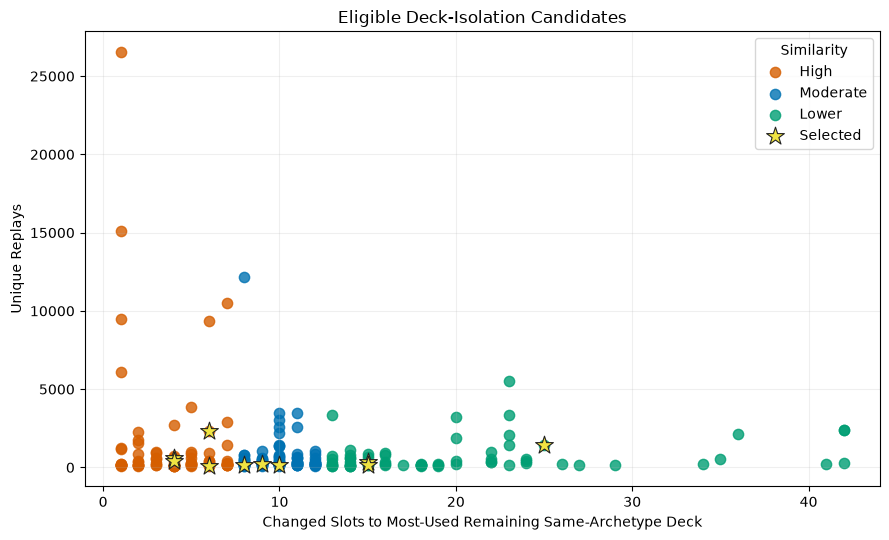

In [ ]:
band_colors = {'high': '#D55E00', 'moderate': '#0072B2', 'lower': '#009E73'}
fig, ax = plt.subplots(figsize=(9, 5.5))
for band in ('high', 'moderate', 'lower'):
    group = eligible_deck_candidates[eligible_deck_candidates['similarity_band'] == band]
    if not group.empty:
        ax.scatter(
            group['reference_changed_slots'], group['replays'],
            s=55, alpha=0.8, color=band_colors[band], label=band.title(),
        )
if not selected_decks.empty:
    ax.scatter(
        selected_decks['reference_changed_slots'], selected_decks['replays'],
        s=180, marker='*', color='#F0E442', edgecolor='#222222',
        linewidth=0.8, label='Selected', zorder=5,
    )
ax.set(
    title='Eligible Deck-Isolation Candidates',
    xlabel='Changed Slots to Most-Used Remaining Same-Archetype Deck',
    ylabel='Unique Replays',
)
ax.grid(alpha=0.2)
if not eligible_deck_candidates.empty or not selected_decks.empty:
    ax.legend(title='Similarity')
plt.tight_layout()
plt.show()

## Archetype Isolation Candidates

Explicit rules and curated `named_fallback_main_pokemon` labels are eligible. Raw fallback labels remain visible but are not sampled. Core-card overlap with other labels is descriptive only.

In [ ]:
ARCHETYPE_MIN_REPLAYS = 100

archetype_isolation_candidates = build_archetype_isolation_candidates(
    annotated_facts,
    catalog,
    min_validation_replays=ARCHETYPE_MIN_REPLAYS,
)
ordinary_archetype_candidates = archetype_isolation_candidates[
    archetype_isolation_candidates['deck_archetype'].ne(TOP_DECK_ARCHETYPE)
].copy()
eligible_archetype_candidates = ordinary_archetype_candidates[
    ordinary_archetype_candidates['eligible']
].copy()
print('Eligible curated archetypes:', len(eligible_archetype_candidates), '/', len(ordinary_archetype_candidates))
display(
    ordinary_archetype_candidates[
        [
            'deck_archetype', 'classification_method', 'core_card_names',
            'replays', 'uses', 'win_rate', 'unique_exact_decks',
            'core_card_other_archetype_decks',
            'core_card_other_archetype_replays', 'rule_defined',
            'sampling_method_allowed', 'eligible',
        ]
    ]
)

Eligible curated archetypes: 27 / 42


,deck_archetype,classification_method,core_card_names,replays,uses,win_rate,unique_exact_decks,core_card_other_archetype_decks,core_card_other_archetype_replays,rule_defined,sampling_method_allowed,eligible
0,Alakazam,rule,Alakazam,77426,91182,0.483242,254,0,0,True,True,True
2,Crustle Wall,rule,Crustle,26013,27881,0.495786,67,9,1699,True,True,True
3,Archaludon,rule,Archaludon ex,19734,22247,0.517373,121,0,0,True,True,True
4,Team Rocket Mewtwo,rule,Team Rocket's Mewtwo ex,16179,16733,0.538218,38,0,0,True,True,True
5,Cynthia Garchomp,rule,Cynthia's Garchomp ex,14754,14948,0.519802,27,0,0,True,True,True
6,Mega Starmie,rule,Mega Starmie ex,12109,12363,0.513144,46,29,3771,True,True,True
7,Dragapult,rule,Dragapult ex,11380,11602,0.498362,65,0,0,True,True,True
8,Mega Lucario,rule,Mega Lucario ex,11145,11988,0.433517,92,0,0,True,True,True
9,Hop Trevenant,rule,Hop's Trevenant,7280,7829,0.450121,52,0,0,True,True,True
10,Cornerstone Mask Ogerpon,named_fallback_main_pokemon,Cornerstone Mask Ogerpon ex,5977,6110,0.492962,8,57,8197,False,True,True


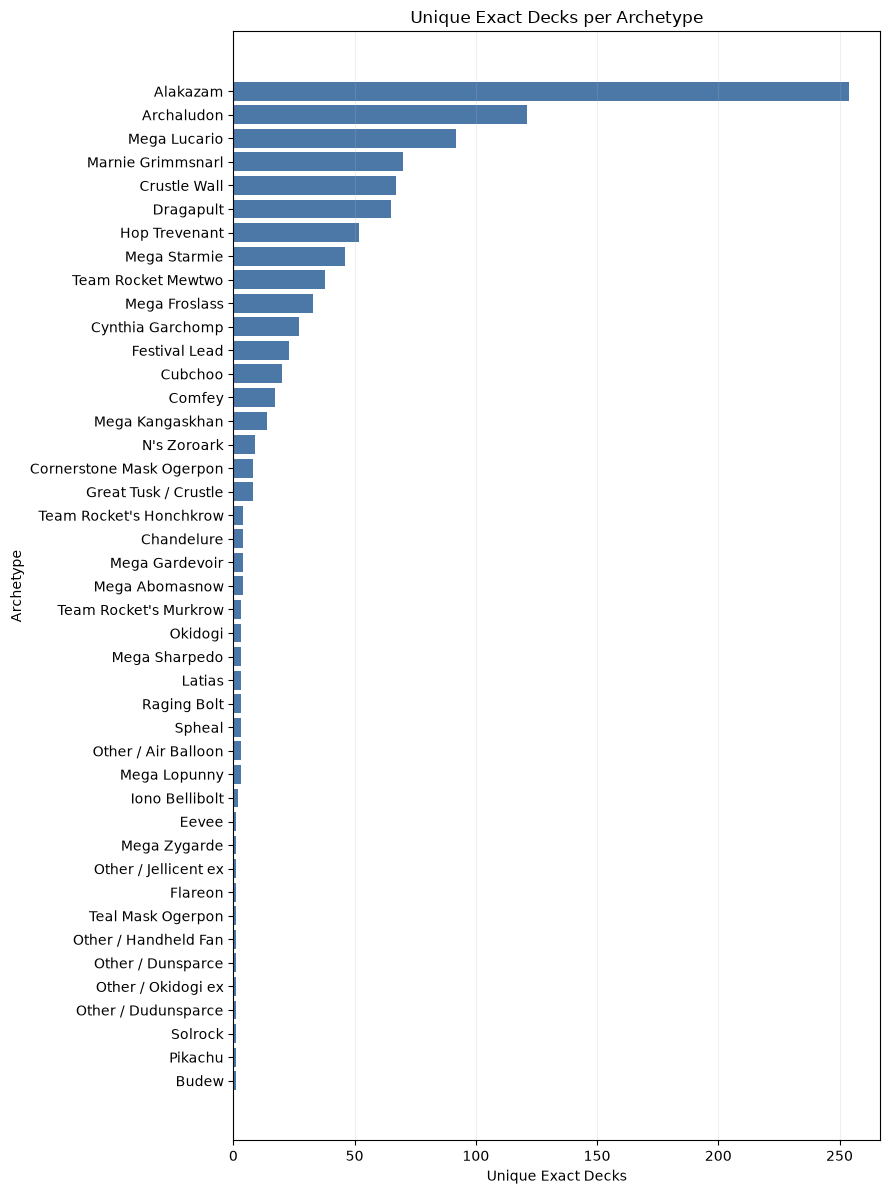

In [ ]:
archetype_counts = archetype_isolation_candidates.sort_values('unique_exact_decks')
fig_height = max(5, 0.28 * len(archetype_counts))
fig, ax = plt.subplots(figsize=(9, fig_height))
ax.barh(
    archetype_counts['deck_archetype'],
    archetype_counts['unique_exact_decks'],
    color='#4C78A8',
)
ax.set(
    title='Unique Exact Decks per Archetype',
    xlabel='Unique Exact Decks',
    ylabel='Archetype',
)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

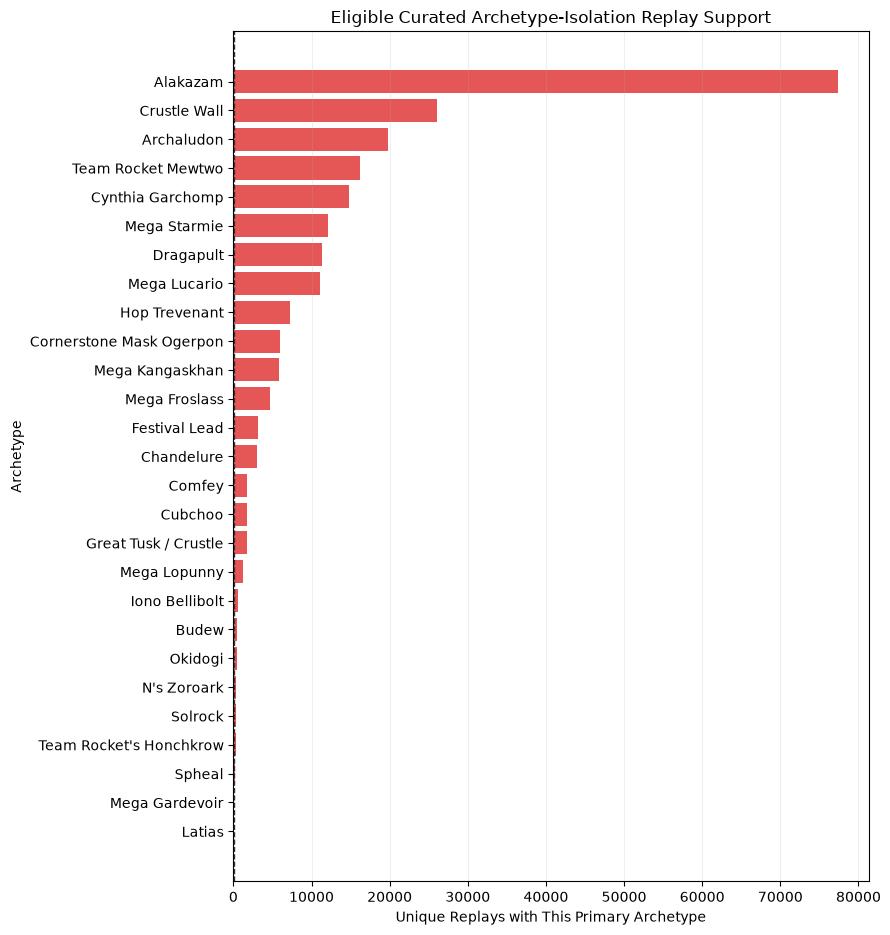

In [ ]:
eligible_archetype_plot = eligible_archetype_candidates.sort_values('replays')
fig_height = max(4, 0.35 * len(eligible_archetype_plot))
fig, ax = plt.subplots(figsize=(9, fig_height))
ax.barh(
    eligible_archetype_plot['deck_archetype'],
    eligible_archetype_plot['replays'],
    color='#E45756',
)
ax.axvline(ARCHETYPE_MIN_REPLAYS, color='#333333', linestyle='--', linewidth=1)
ax.set(
    title='Eligible Curated Archetype-Isolation Replay Support',
    xlabel='Unique Replays with This Primary Archetype',
    ylabel='Archetype',
)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

## Archetype Isolation Roll

Change `ARCHETYPE_ROLL_ID` and rerun this cell to obtain another reproducible roll. Eligible rule or curated named-fallback archetypes have equal sampling weight.

In [ ]:
ARCHETYPE_MIN_COUNT = 3
ARCHETYPE_TOTAL_REPLAYS_MIN = 2000
ARCHETYPE_TOTAL_REPLAYS_MAX = 4000
ARCHETYPE_ROLL_ID = 0
ARCHETYPE_SELECTION_PATH = PROJECT_ROOT / 'data' / 'archetype_isolation_selection.csv'

archetype_roll = None
selected_archetype_summary = pd.DataFrame()
selected_archetype_decks = pd.DataFrame()
try:
    archetype_roll = roll_archetype_isolation_selection(
        annotated_facts,
        archetype_isolation_candidates,
        min_count=ARCHETYPE_MIN_COUNT,
        total_replays_min=ARCHETYPE_TOTAL_REPLAYS_MIN,
        total_replays_max=ARCHETYPE_TOTAL_REPLAYS_MAX,
        roll_id=ARCHETYPE_ROLL_ID,
        excluded_archetypes=(TOP_DECK_ARCHETYPE,),
    )
    selected_archetype_summary = archetype_isolation_candidates[
        archetype_isolation_candidates['deck_archetype'].isin(archetype_roll.selected)
    ].copy()
    selection_order = {
        archetype: index for index, archetype in enumerate(archetype_roll.selected)
    }
    selected_archetype_summary['selection_order'] = (
        selected_archetype_summary['deck_archetype'].map(selection_order)
    )
    selected_archetype_summary = selected_archetype_summary.sort_values('selection_order')
    selected_archetype_summary = selected_archetype_summary[
        [
            'deck_archetype', 'core_card_names', 'replays', 'uses',
            'win_rate', 'unique_exact_decks',
            'core_card_other_archetype_decks',
            'core_card_other_archetype_replays',
        ]
    ]
    selected_archetype_decks = build_archetype_selection_details(
        annotated_facts, archetype_roll.selected
    )
    print('Selected archetypes:')
    display(selected_archetype_summary)
    print('Selected archetype exact decks:')
    display(selected_archetype_decks)
    print('Selected unique replays:', archetype_roll.replay_count)
    print('Sampling attempts:', archetype_roll.attempts)
    selected_archetype_decks.to_csv(
        ARCHETYPE_SELECTION_PATH, index=False, encoding='utf-8-sig'
    )
    print('Saved:', ARCHETYPE_SELECTION_PATH)
except (IsolationSamplingError, ValueError) as exc:
    print('Archetype Isolation roll failed:', exc)
    if isinstance(exc, IsolationSamplingError):
        display(pd.DataFrame([exc.diagnostics]))
    print('Existing selection CSV was not overwritten.')

Selected archetypes:


,deck_archetype,core_card_names,replays,uses,win_rate,unique_exact_decks,core_card_other_archetype_decks,core_card_other_archetype_replays
25,Spheal,Spheal,250,250,0.416000,3,5,347
19,Iono Bellibolt,Iono’s Bellibolt ex,618,618,0.389968,2,0,0
26,Mega Gardevoir,Mega Gardevoir ex,125,125,0.432000,4,0,0
20,Budew,Budew,419,419,0.482100,1,99,21429
18,Mega Lopunny,Mega Lopunny ex,1218,1224,0.510621,3,15,1053


Selected archetype exact decks:


,deck_archetype,deck_id,replays,uses,wins,win_rate,card_ids
0,Budew,D-3CD2CF7A0DAF,419,419,202,0.482100,"[3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,235,235,2..."
1,Iono Bellibolt,D-7DC29BA6002F,617,617,241,0.390600,"[4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,2..."
2,Iono Bellibolt,D-D4F73AC2855F,1,1,0,0.000000,"[4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,265..."
3,Mega Gardevoir,D-3127B307579A,65,65,32,0.492308,"[5,5,5,5,5,5,5,16,16,16,19,19,19,19,112,112,11..."
4,Mega Gardevoir,D-9A6B007735E0,33,33,11,0.333333,"[5,5,5,5,5,5,5,16,16,16,19,19,19,19,112,112,11..."
5,Mega Gardevoir,D-91935C6E8529,26,26,10,0.384615,"[5,5,5,5,5,5,5,16,16,16,19,19,19,19,112,112,11..."
6,Mega Gardevoir,D-42825D50E165,1,1,1,1.000000,"[5,5,5,5,5,5,5,16,16,16,19,19,19,19,112,112,11..."
7,Mega Lopunny,D-053B4950D40B,688,688,346,0.502907,"[11,11,11,11,13,14,14,14,66,66,66,66,174,305,3..."
8,Mega Lopunny,D-9043CFF10C52,329,329,164,0.498480,"[2,2,2,11,11,11,11,13,65,66,66,66,109,174,305,..."
9,Mega Lopunny,D-B26D0342A3E7,207,207,115,0.555556,"[4,4,4,11,11,11,11,13,66,66,66,174,305,305,305..."


Selected unique replays: 2629
Sampling attempts: 1
Saved: D:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\archetype_isolation_selection.csv


## Combined Audit

This audit simulates removing all three selected replay unions together. It checks exact-deck, Card-ID, same-archetype, selected-archetype, and exact-top-deck exclusion conditions without forbidding the top deck as an opponent.

In [ ]:
if deck_roll is None or archetype_roll is None or top_deck_roll is None:
    print('Combined audit unavailable: all three roll cells must succeed.')
else:
    combined_selected_deck_ids = (
        tuple(deck_roll.selected) + tuple(top_deck_roll.selected)
    )
    combined_audit = audit_deck_archetype_selection(
        annotated_facts,
        selected_deck_ids=combined_selected_deck_ids,
        selected_archetypes=archetype_roll.selected,
    )
    ordinary_replays = set(
        annotated_facts.loc[
            annotated_facts['deck_id'].isin(deck_roll.selected), 'replay_key'
        ].astype(str)
    )
    top_variant_replays = set(
        annotated_facts.loc[
            annotated_facts['deck_id'].isin(top_deck_roll.selected), 'replay_key'
        ].astype(str)
    )
    combined_audit['ordinary_deck_isolation_replays'] = len(ordinary_replays)
    combined_audit['top_deck_archetype_isolation_replays'] = len(top_variant_replays)
    combined_audit['ordinary_top_variant_overlap_replays'] = len(
        ordinary_replays & top_variant_replays
    )
    combined_audit['top_deck_selected'] = (
        TOP_DECK_ID in combined_selected_deck_ids
    )
    combined_audit['valid'] = (
        combined_audit['valid'] and not combined_audit['top_deck_selected']
    )
    display(pd.DataFrame([combined_audit]))

## Next Steps

Review all three selected tables and the combined audit. Change the corresponding `ROLL_ID` and rerun its cell until the selection is acceptable. The three CSV files under `imitation_learning/data/` are then ready for the later training-data split task.